In [4]:
!pip install statsmodels


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt

In [14]:
df = pd.read_csv("TSLA.csv")

In [15]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,3.800,5.000,3.508,4.778,4.778,93831500
1,2010-06-30,5.158,6.084,4.660,4.766,4.766,85935500
2,2010-07-01,5.000,5.184,4.054,4.392,4.392,41094000
3,2010-07-02,4.600,4.620,3.742,3.840,3.840,25699000
4,2010-07-06,4.000,4.000,3.166,3.222,3.222,34334500


In [16]:
df.shape

(2956, 7)

In [17]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

In [18]:
df.isnull().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [19]:
df.info

<bound method DataFrame.info of                    Open         High         Low        Close    Adj Close  \
Date                                                                         
2010-06-29     3.800000     5.000000    3.508000     4.778000     4.778000   
2010-06-30     5.158000     6.084000    4.660000     4.766000     4.766000   
2010-07-01     5.000000     5.184000    4.054000     4.392000     4.392000   
2010-07-02     4.600000     4.620000    3.742000     3.840000     3.840000   
2010-07-06     4.000000     4.000000    3.166000     3.222000     3.222000   
...                 ...          ...         ...          ...          ...   
2022-03-18   874.489990   907.849976  867.390015   905.390015   905.390015   
2022-03-21   914.979980   942.849976  907.090027   921.159973   921.159973   
2022-03-22   930.000000   997.859985  921.750000   993.979980   993.979980   
2022-03-23   979.940002  1040.699951  976.400024   999.109985   999.109985   
2022-03-24  1009.729980  1024.48

In [20]:
series = df['Close'].dropna()

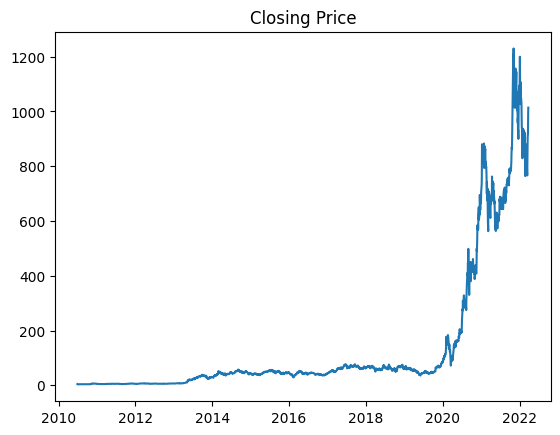

In [21]:
plt.figure()
plt.plot(series)
plt.title("Closing Price")
plt.show()

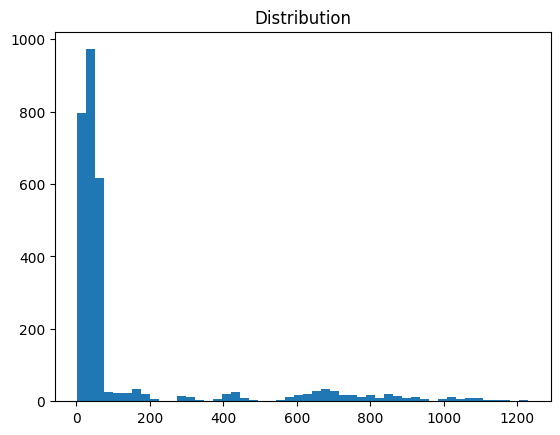

In [22]:
plt.figure()
plt.hist(series, bins=50)
plt.title("Distribution")
plt.show()

In [23]:
log_series = np.log(series)

In [24]:
train_size = int(len(log_series) * 0.8)
train, test = log_series[:train_size], log_series[train_size:]

In [25]:
model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

C:\Users\Parth\PycharmProjects\PythonProject3\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Parth\PycharmProjects\PythonProject3\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Parth\PycharmProjects\PythonProject3\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [26]:
forecast = model_fit.forecast(steps=len(test))

C:\Users\Parth\PycharmProjects\PythonProject3\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Parth\PycharmProjects\PythonProject3\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [27]:
forecast = np.exp(forecast)
test_actual = np.exp(test)


In [28]:
rmse = sqrt(mean_squared_error(test_actual, forecast))

In [29]:
print("RMSE:", rmse)

RMSE: 573.4907350966238


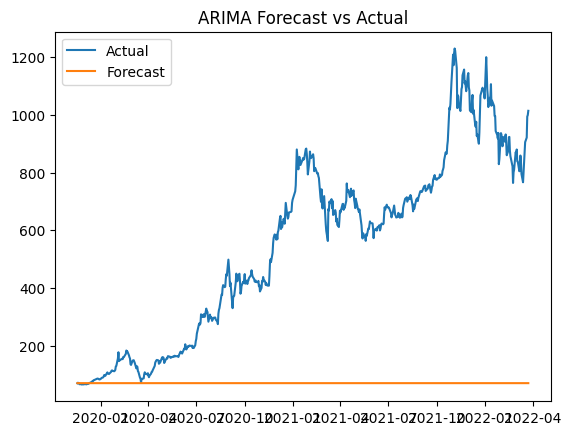

In [30]:
plt.figure()
plt.plot(test_actual.index, test_actual, label='Actual')
plt.plot(test_actual.index, forecast, label='Forecast')
plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()


In [31]:
future_steps = 30
future_forecast = model_fit.forecast(steps=future_steps)
future_forecast = np.exp(future_forecast)

C:\Users\Parth\PycharmProjects\PythonProject3\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Parth\PycharmProjects\PythonProject3\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [32]:
future_dates = pd.date_range(start=series.index[-1], periods=future_steps+1, freq='D')[1:]

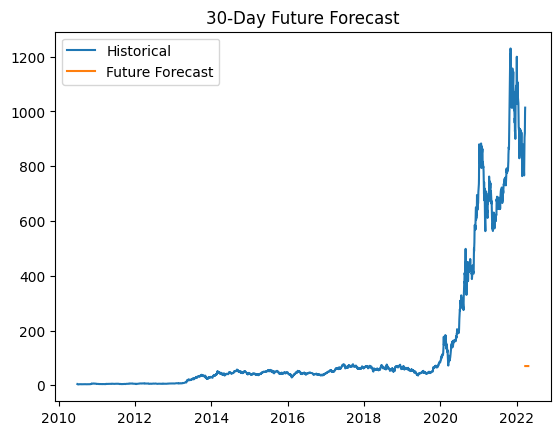

In [33]:
plt.figure()
plt.plot(series.index, series, label='Historical')
plt.plot(future_dates, future_forecast, label='Future Forecast')
plt.legend()
plt.title("30-Day Future Forecast")
plt.show()

In [37]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(test_actual, forecast)
mape = np.mean(np.abs((test_actual - forecast) / test_actual)) * 100
accuracy = 100 - mape
print("MAE:", mae)
print("MAPE:", mape)
print("Approx Accuracy (%):", accuracy)

MAE: 478.20588476631383
MAPE: nan
Approx Accuracy (%): nan


C:\Users\Parth\AppData\Local\Temp\ipykernel_4132\3172656570.py:3: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  mape = np.mean(np.abs((test_actual - forecast) / test_actual)) * 100


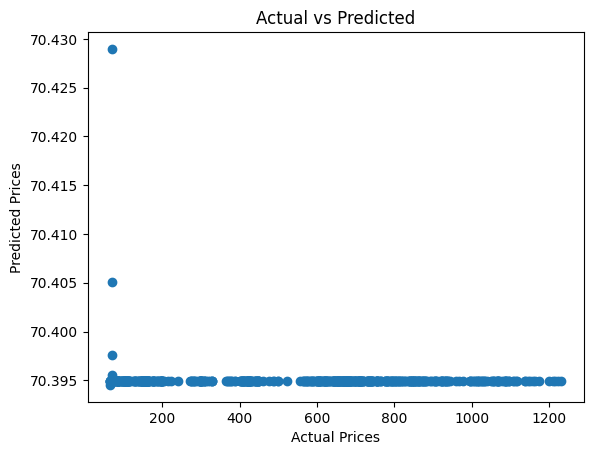

In [39]:
plt.figure()
plt.scatter(test_actual, forecast)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()

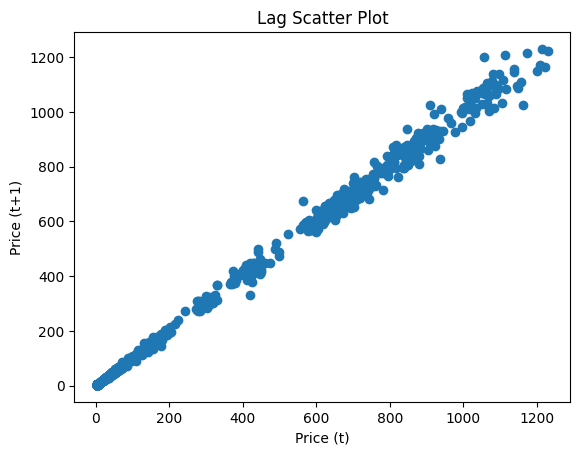

In [40]:
lag = 1
plt.figure()
plt.scatter(series[:-lag], series[lag:])
plt.xlabel("Price (t)")
plt.ylabel("Price (t+1)")
plt.title("Lag Scatter Plot")
plt.show()

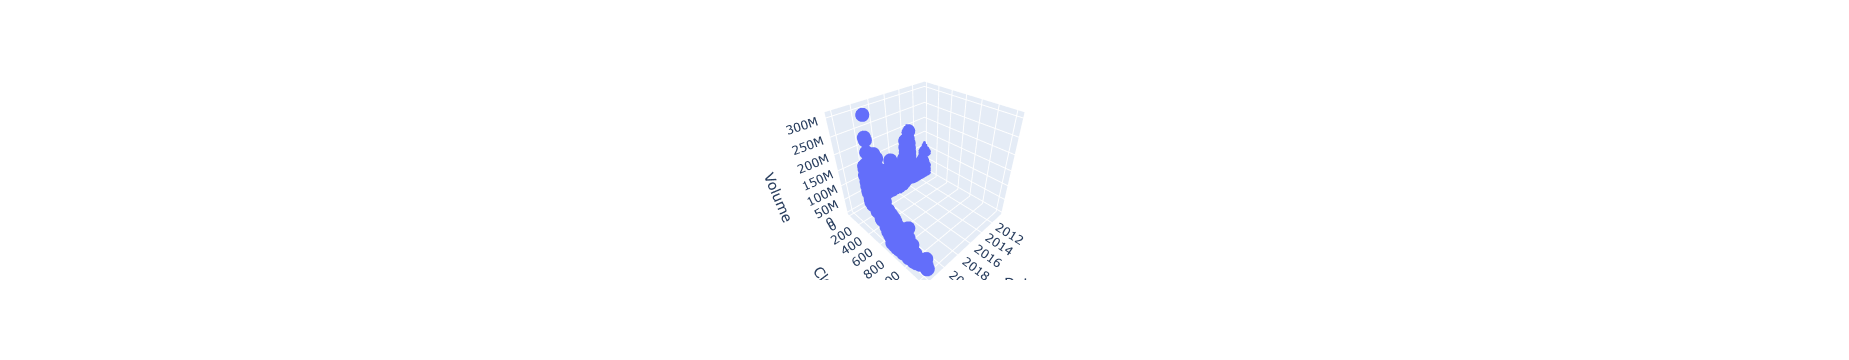

In [41]:
import plotly.express as px

df_plot = df.reset_index()

fig = px.scatter_3d(
    df_plot,
    x='Date',
    y='Close',
    z='Volume',
)

fig.show()

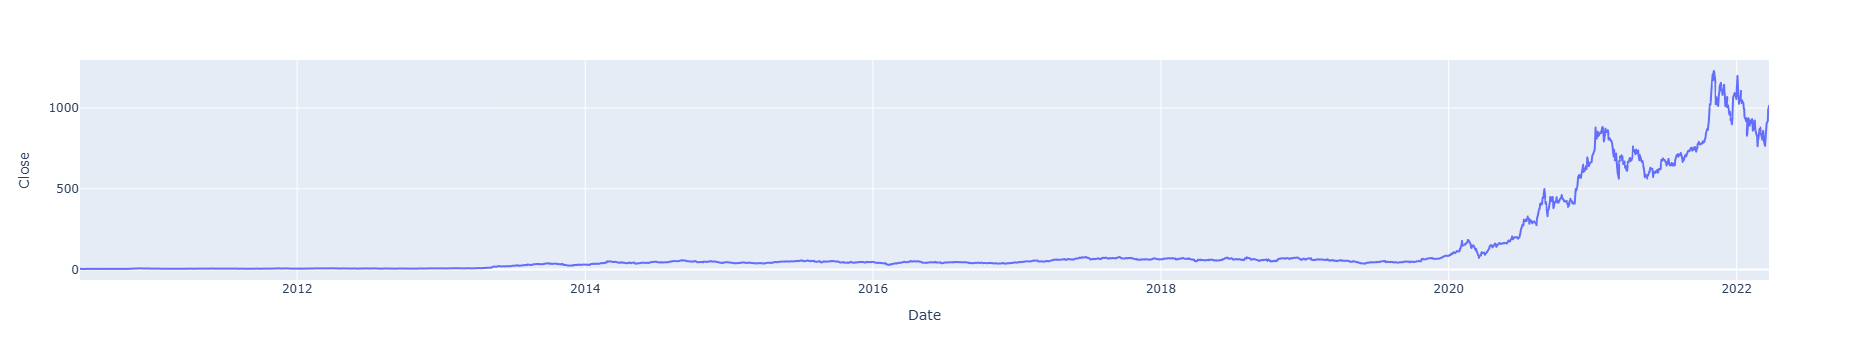

In [42]:
fig = px.line(
    df_plot,
    x='Date',
    y='Close'
)

fig.show()